# Baseline Compressor Controller

This notebook validates AeroXAI's **conventional simulated baseline controller**.

The controller is intentionally simple:

- fixed compressor priority,
- pressure-band hysteresis,
- minimum ON/OFF times,
- VSD residual control.

All compressor specifications, demand values, leak values, and energy results in this notebook are **simulated assumptions**, not MetroPT measurements and not claims about a specific industrial plant.

The notebook reuses the tested controller implementation from `ml/control/baseline.py` and compressor model from `ml/twin/compressor.py`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

ROOT = Path.cwd().resolve()

if (
    not (ROOT / "ml").exists()
    and (ROOT.parent / "ml").exists()
):
    ROOT = ROOT.parent

if not (ROOT / "ml").exists():
    raise RuntimeError(
        "Could not locate repository root."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(ROOT),
    )

from ml.control.baseline import (
    BaselineControllerConfig,
    simulate_baseline,
)
from ml.twin.compressor import CompressorSpec
from ml.twin.physics import TwinParameters

print("Repository root:", ROOT)

Repository root: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor


## Load simulation configuration

The compressor fleet and pressure-band settings below come from `configs/compressors.yaml`. The receiver and air assumptions come from `configs/twin.yaml`.

In [2]:
COMPRESSOR_CONFIG_PATH = (
    ROOT
    / "configs"
    / "compressors.yaml"
)

TWIN_CONFIG_PATH = (
    ROOT
    / "configs"
    / "twin.yaml"
)

with COMPRESSOR_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    compressor_config = yaml.safe_load(handle)

with TWIN_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    twin_config = yaml.safe_load(handle)

compressors = [
    CompressorSpec(
        id=str(item["id"]),
        kind=str(item["kind"]),
        max_mass_flow_kg_s=float(
            item["max_mass_flow_kg_s"]
        ),
        rated_power_kw=float(
            item["rated_power_kw"]
        ),
        idle_power_kw=float(
            item["idle_power_kw"]
        ),
        min_load_fraction=float(
            item["min_load_fraction"]
        ),
        min_on_seconds=float(
            item["min_on_seconds"]
        ),
        min_off_seconds=float(
            item["min_off_seconds"]
        ),
    )
    for item in compressor_config[
        "compressors"
    ]
]

pressure_config = compressor_config[
    "pressure"
]
controller_raw = compressor_config[
    "controller"
]

controller = BaselineControllerConfig(
    target_bar_g=float(
        pressure_config[
            "target_bar_g"
        ]
    ),
    lower_band_bar_g=float(
        pressure_config[
            "lower_band_bar_g"
        ]
    ),
    upper_band_bar_g=float(
        pressure_config[
            "upper_band_bar_g"
        ]
    ),
    safety_min_bar_g=float(
        pressure_config[
            "safety_min_bar_g"
        ]
    ),
    safety_max_bar_g=float(
        pressure_config[
            "safety_max_bar_g"
        ]
    ),
    pressure_gain_kg_s_per_bar=float(
        controller_raw[
            "pressure_gain_kg_s_per_bar"
        ]
    ),
)

air_config = twin_config["air"]
receiver_config = twin_config["receiver"]
simulation_config = twin_config[
    "simulation"
]

parameters = TwinParameters(
    volume_m3=float(
        receiver_config["volume_m3"]
    ),
    temperature_k=float(
        air_config["temperature_k"]
    ),
    gas_constant_j_per_kg_k=float(
        air_config[
            "gas_constant_j_per_kg_k"
        ]
    ),
    ambient_pressure_pa=float(
        air_config[
            "ambient_pressure_pa"
        ]
    ),
)

timestep_seconds = float(
    simulation_config[
        "timestep_seconds"
    ]
)

nominal_leak_kg_s = float(
    compressor_config[
        "scenario"
    ][
        "nominal_leak_kg_s"
    ]
)

compressors

[CompressorSpec(id='fixed_1', kind='fixed', max_mass_flow_kg_s=0.06, rated_power_kw=13.0, idle_power_kw=0.0, min_load_fraction=1.0, min_on_seconds=120.0, min_off_seconds=60.0),
 CompressorSpec(id='fixed_2', kind='fixed', max_mass_flow_kg_s=0.06, rated_power_kw=13.0, idle_power_kw=0.0, min_load_fraction=1.0, min_on_seconds=120.0, min_off_seconds=60.0),
 CompressorSpec(id='vsd_1', kind='vsd', max_mass_flow_kg_s=0.08, rated_power_kw=19.0, idle_power_kw=2.0, min_load_fraction=0.2, min_on_seconds=60.0, min_off_seconds=30.0)]

## One-hour synthetic demand profile

The profile is deliberately simple so the controller behavior is easy to inspect:

- 0–15 min: 0.070 kg/s
- 15–30 min: 0.110 kg/s
- 30–45 min: 0.145 kg/s
- 45–60 min: 0.090 kg/s

This is simulated evidence only.

In [3]:
seconds_per_block = 15 * 60

demand_profile = (
    [0.070] * seconds_per_block
    + [0.110] * seconds_per_block
    + [0.145] * seconds_per_block
    + [0.090] * seconds_per_block
)

len(demand_profile)

3600

## Run the nominal-leak baseline

The controller starts from 7.0 bar gauge and uses the frozen conventional pressure-band logic.

In [4]:
baseline = simulate_baseline(
    demand_profile,
    leak_mass_flow_kg_s=(
        nominal_leak_kg_s
    ),
    initial_pressure_bar_g=7.0,
    parameters=parameters,
    compressors=compressors,
    controller_config=controller,
    timestep_seconds=timestep_seconds,
)

baseline.head()

,time_seconds,demand_kg_s,leak_kg_s,desired_flow_kg_s,pressure_start_bar_g,pressure_bar_g,compressor_flow_kg_s,power_kw,energy_kwh,cumulative_energy_kwh,safety_violation,fixed_1_on,fixed_1_start,fixed_2_on,fixed_2_start,vsd_1_on,vsd_1_fraction,vsd_1_start
0,1.0,0.07,0.005,0.075,7.0,7.0,0.075,17.9375,0.004983,0.004983,False,False,False,False,False,True,0.9375,True
1,2.0,0.07,0.005,0.075,7.0,7.0,0.075,17.9375,0.004983,0.009965,False,False,False,False,False,True,0.9375,False
2,3.0,0.07,0.005,0.075,7.0,7.0,0.075,17.9375,0.004983,0.014948,False,False,False,False,False,True,0.9375,False
3,4.0,0.07,0.005,0.075,7.0,7.0,0.075,17.9375,0.004983,0.019931,False,False,False,False,False,True,0.9375,False
4,5.0,0.07,0.005,0.075,7.0,7.0,0.075,17.9375,0.004983,0.024913,False,False,False,False,False,True,0.9375,False


In [5]:
baseline_energy_kwh = float(
    baseline[
        "cumulative_energy_kwh"
    ].iloc[-1]
)

baseline_min_pressure = float(
    baseline[
        "pressure_bar_g"
    ].min()
)

baseline_max_pressure = float(
    baseline[
        "pressure_bar_g"
    ].max()
)

baseline_safety_violations = int(
    baseline[
        "safety_violation"
    ].sum()
)

start_columns = [
    column
    for column in baseline.columns
    if column.endswith("_start")
]

baseline_start_count = int(
    baseline[
        start_columns
    ].sum().sum()
)

print(
    "Baseline energy:",
    baseline_energy_kwh,
    "kWh",
)

print(
    "Pressure range:",
    baseline_min_pressure,
    "to",
    baseline_max_pressure,
    "bar(g)",
)

print(
    "Startup count:",
    baseline_start_count,
)

print(
    "Safety violations:",
    baseline_safety_violations,
)

Baseline energy: 25.311174554824547 kWh
Pressure range: 6.799305619662522 to 7.201742631845943 bar(g)
Startup count: 4
Safety violations: 0


## Pressure behavior

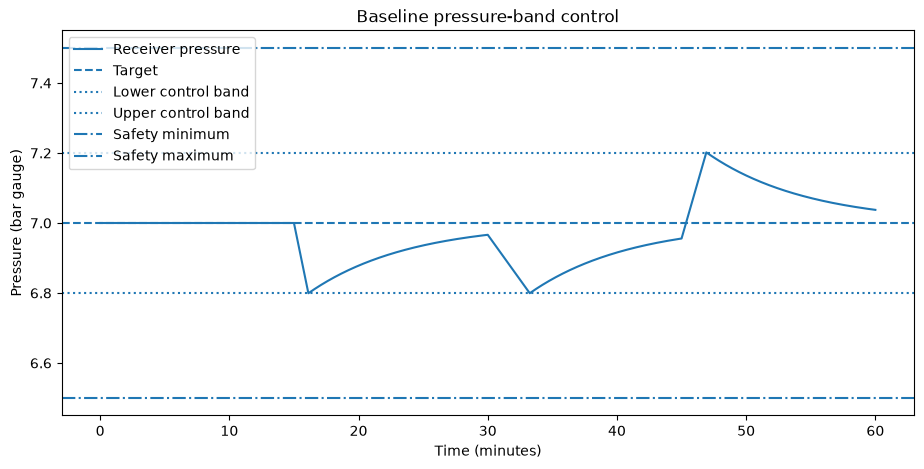

In [6]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

time_minutes = (
    baseline["time_seconds"]
    / 60.0
)

ax.plot(
    time_minutes,
    baseline["pressure_bar_g"],
    label="Receiver pressure",
)

ax.axhline(
    controller.target_bar_g,
    linestyle="--",
    label="Target",
)

ax.axhline(
    controller.lower_band_bar_g,
    linestyle=":",
    label="Lower control band",
)

ax.axhline(
    controller.upper_band_bar_g,
    linestyle=":",
    label="Upper control band",
)

ax.axhline(
    controller.safety_min_bar_g,
    linestyle="-.",
    label="Safety minimum",
)

ax.axhline(
    controller.safety_max_bar_g,
    linestyle="-.",
    label="Safety maximum",
)

ax.set_title(
    "Baseline pressure-band control"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Pressure (bar gauge)"
)

ax.legend(
    loc="best"
)

plt.show()

## Demand and supplied-air behavior

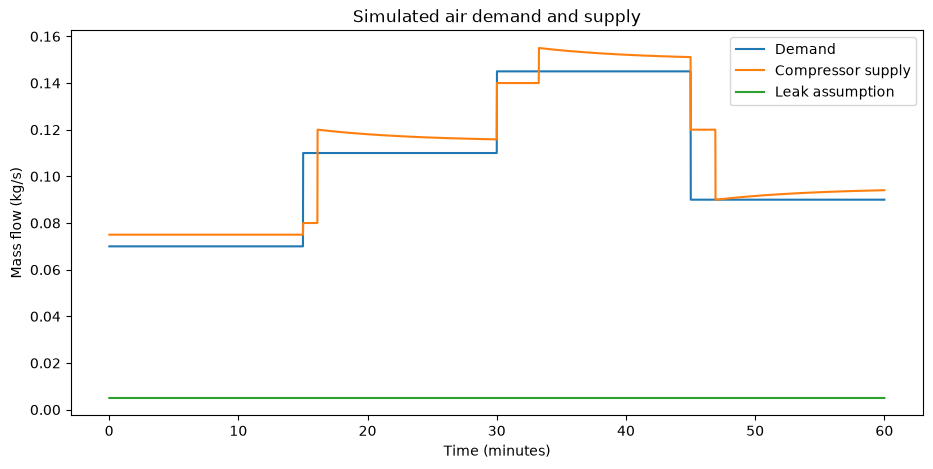

In [7]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    time_minutes,
    baseline["demand_kg_s"],
    label="Demand",
)

ax.plot(
    time_minutes,
    baseline[
        "compressor_flow_kg_s"
    ],
    label="Compressor supply",
)

ax.plot(
    time_minutes,
    baseline["leak_kg_s"],
    label="Leak assumption",
)

ax.set_title(
    "Simulated air demand and supply"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Mass flow (kg/s)"
)

ax.legend()

plt.show()

## Compressor operating states

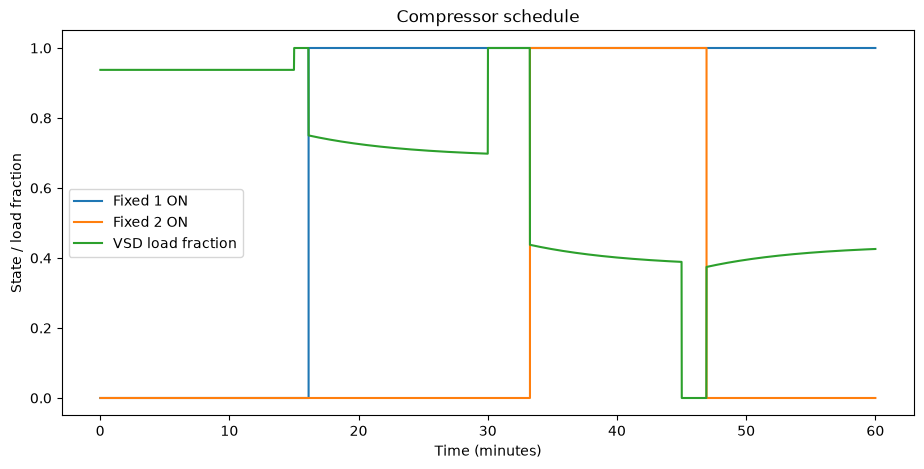

In [8]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.step(
    time_minutes,
    baseline["fixed_1_on"].astype(int),
    where="post",
    label="Fixed 1 ON",
)

ax.step(
    time_minutes,
    baseline["fixed_2_on"].astype(int),
    where="post",
    label="Fixed 2 ON",
)

ax.plot(
    time_minutes,
    baseline["vsd_1_fraction"],
    label="VSD load fraction",
)

ax.set_title(
    "Compressor schedule"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "State / load fraction"
)

ax.legend()

plt.show()

## Power and cumulative energy

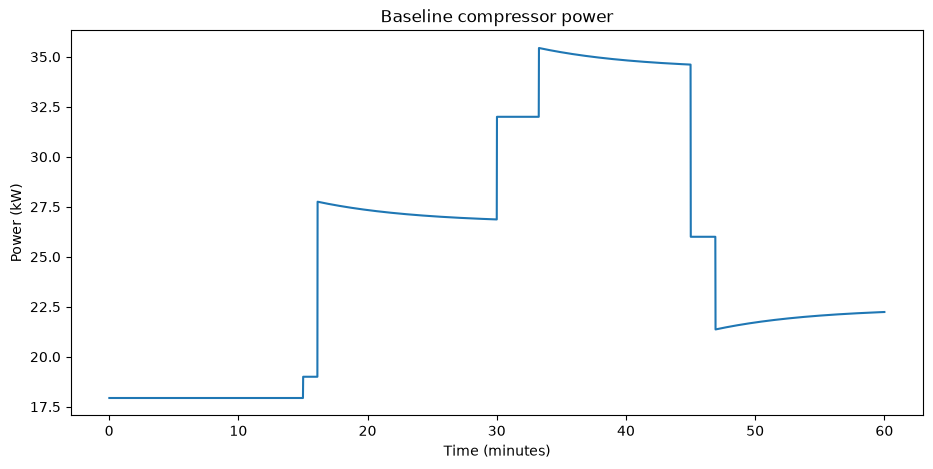

In [9]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    time_minutes,
    baseline["power_kw"],
)

ax.set_title(
    "Baseline compressor power"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Power (kW)"
)

plt.show()

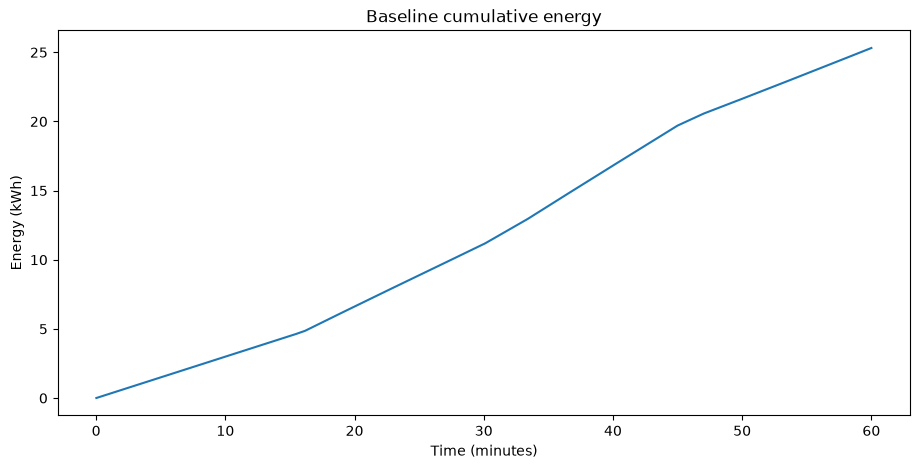

In [10]:
fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    time_minutes,
    baseline[
        "cumulative_energy_kwh"
    ],
)

ax.set_title(
    "Baseline cumulative energy"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Energy (kWh)"
)

plt.show()

## Simulated leakage energy penalty

This comparison changes only the imposed leak rate. It does **not** infer a leak rate from MetroPT.

The result should be interpreted as:

> under this declared simulated operating scenario, a larger imposed leakage rate causes the baseline controller to consume additional predicted energy.


In [11]:
high_leak_kg_s = 0.020

high_leak = simulate_baseline(
    demand_profile,
    leak_mass_flow_kg_s=(
        high_leak_kg_s
    ),
    initial_pressure_bar_g=7.0,
    parameters=parameters,
    compressors=compressors,
    controller_config=controller,
    timestep_seconds=timestep_seconds,
)

high_leak_energy_kwh = float(
    high_leak[
        "cumulative_energy_kwh"
    ].iloc[-1]
)

additional_energy_kwh = (
    high_leak_energy_kwh
    - baseline_energy_kwh
)

additional_energy_percent = (
    additional_energy_kwh
    / baseline_energy_kwh
    * 100.0
)

high_leak_safety_violations = int(
    high_leak[
        "safety_violation"
    ].sum()
)

print(
    "Nominal-leak energy:",
    baseline_energy_kwh,
    "kWh",
)

print(
    "High-leak energy:",
    high_leak_energy_kwh,
    "kWh",
)

print(
    "Additional energy:",
    additional_energy_kwh,
    "kWh",
)

print(
    "Additional energy:",
    additional_energy_percent,
    "%",
)

print(
    "High-leak safety violations:",
    high_leak_safety_violations,
)

Nominal-leak energy: 25.311174554824547 kWh
High-leak energy: 28.48898360884331 kWh
Additional energy: 3.1778090540187627 kWh
Additional energy: 12.554964792864748 %
High-leak safety violations: 0


## Write baseline-controller evidence

In [12]:
REPORT_PATH = (
    ROOT
    / "docs"
    / "baseline_controller_report.json"
)

report = {
    "evidence_class": "simulated",

    "controller": {
        "type":
            "pressure_band_baseline",
        "target_bar_g":
            controller.target_bar_g,
        "lower_band_bar_g":
            controller.lower_band_bar_g,
        "upper_band_bar_g":
            controller.upper_band_bar_g,
        "safety_min_bar_g":
            controller.safety_min_bar_g,
        "safety_max_bar_g":
            controller.safety_max_bar_g,
        "pressure_gain_kg_s_per_bar":
            controller
            .pressure_gain_kg_s_per_bar,
    },

    "scenario": {
        "duration_seconds":
            len(demand_profile)
            * timestep_seconds,
        "timestep_seconds":
            timestep_seconds,
        "initial_pressure_bar_g":
            7.0,
        "nominal_leak_kg_s":
            nominal_leak_kg_s,
        "high_leak_kg_s":
            high_leak_kg_s,
        "demand_blocks_kg_s": [
            0.070,
            0.110,
            0.145,
            0.090,
        ],
        "block_duration_seconds":
            seconds_per_block,
    },

    "baseline": {
        "energy_kwh":
            baseline_energy_kwh,
        "minimum_pressure_bar_g":
            baseline_min_pressure,
        "maximum_pressure_bar_g":
            baseline_max_pressure,
        "startup_count":
            baseline_start_count,
        "safety_violations":
            baseline_safety_violations,
    },

    "leak_comparison": {
        "nominal_energy_kwh":
            baseline_energy_kwh,
        "high_leak_energy_kwh":
            high_leak_energy_kwh,
        "additional_energy_kwh":
            additional_energy_kwh,
        "additional_energy_percent":
            additional_energy_percent,
        "high_leak_safety_violations":
            high_leak_safety_violations,
    },

    "limitations": [
        (
            "All compressor specifications "
            "are simulation assumptions."
        ),
        (
            "The demand profile is synthetic."
        ),
        (
            "Leak rates are imposed scenario "
            "inputs, not inferred from MetroPT."
        ),
        (
            "The compressor power model is "
            "simplified."
        ),
        (
            "The baseline controller is a "
            "simulated conventional reference, "
            "not a reproduction of a specific "
            "industrial controller."
        ),
        (
            "No optimization is applied in "
            "this report."
        ),
    ],
}

REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_PATH.write_text(
    json.dumps(
        report,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Baseline controller report written to:",
    REPORT_PATH,
)

Baseline controller report written to: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor/docs/baseline_controller_report.json


## Interpretation

This notebook establishes the conventional simulated reference against which the future constrained optimizer will be compared.

The baseline result must be frozen before optimization. The optimizer should be evaluated on the **same** demand profile, compressor assumptions, leak assumption, timestep, and pressure-safety limits.